# 3I - Interpretacao integrada da Fase 3 (Pacifico; P90/P95)

**Pergunta especifica.** Depois de 3A-3H/3K, qual e a leitura fisica defensavel do Nino 3.4, quais evidencias entram no parecer, como ficam as duas classes `forte_p90` e `super_p95`, e como ler a janela 2026?

**Objetivo.** Consolidar evidencias/limites em saida unica rastreavel a tabelas ja materializadas.

**Justificativa.** Evita interpretacao solta e elimina classificacoes antigas. **Escopo estritamente Pacifico** - indices atlanticos foram removidos da Fase 3.

**Metodologia.** Le features/statistics; usa P90/P95 da OISST local; classes abaixo ou iguais a P90 sao descartadas da leitura por classe.

**Saidas.** `phase3I_conclusoes_decisao.csv`, `phase3I_picos_p90_p95_comparacao.csv`, `phase3I_estado_2026.csv`, figura-sintese.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
d3=pd.read_csv(u.STATS/'phase3D_ranking_significativo.csv').set_index('variavel')
e3=pd.read_csv(u.STATS/'phase3E_estabilidade.csv').set_index('variavel')
assert not any('atl' in v for v in d3.index), 'Atlantico ainda presente!'
print('Variaveis no parecer (todas Pacifico):',list(d3.index))
bloco={'tilt_m':'recarga/subsuperficie','ssh_m':'recarga/subsuperficie','ohc_0_300':'recarga/subsuperficie','ohc_0_700':'recarga/subsuperficie','d20_m':'recarga/subsuperficie','wwv':'recarga/subsuperficie','tau_x_proxy_nino34_pa':'vento/acoplamento','dhw_12w':'calor acumulado'}
rows=[]
for v in d3.index:
    est=bool(e3.loc[v,'estavel']) if v in e3.index else False
    lag=int(d3.loc[v,'lag_semanas'])
    papel='estado simultaneo/curto prazo' if lag<=1 else 'precursor de medio prazo'
    status='entra' if est else 'entra como ressalva (regime-dependente)'
    rows.append({'variavel':v,'bloco':bloco.get(v,'-'),'lag_semanas':lag,'r':round(d3.loc[v,'r'],3),'estavel_3E':est,'papel':papel,'uso_parecer':status})
conc=pd.DataFrame(rows); u.save_table(conc,'phase3I_conclusoes_decisao.csv',index=False); conc

Variaveis no parecer (todas Pacifico): ['tilt_m', 'ssh_m', 'ohc_0_300', 'ohc_0_700', 'dhw_12w', 'd20_m', 'wwv', 'tau_x_proxy_nino34_pa']
[tabela] data\processed\parquet\statistics\phase3I_conclusoes_decisao.csv


,variavel,bloco,lag_semanas,r,estavel_3E,papel,uso_parecer
0,tilt_m,recarga/subsuperficie,0,0.772,True,estado simultaneo/curto prazo,entra
1,ssh_m,recarga/subsuperficie,6,0.755,True,precursor de medio prazo,entra
2,ohc_0_300,recarga/subsuperficie,6,0.738,True,precursor de medio prazo,entra
3,ohc_0_700,recarga/subsuperficie,6,0.701,True,precursor de medio prazo,entra
4,dhw_12w,calor acumulado,0,0.600,False,estado simultaneo/curto prazo,entra como ressalva (regime-dependente)
5,d20_m,recarga/subsuperficie,15,0.545,True,precursor de medio prazo,entra
6,wwv,recarga/subsuperficie,20,0.516,False,precursor de medio prazo,entra como ressalva (regime-dependente)
7,tau_x_proxy_nino34_pa,vento/acoplamento,1,0.442,True,estado simultaneo/curto prazo,entra


In [2]:
p90= u.load_p90_peaks(); p95 = u.load_p95_peaks()
ev_all = u.add_p90_p95_classification(u.load_events())
ev_cls = ev_all['classe_p90_p95'].value_counts().to_dict()
comp=pd.DataFrame({
 'forte_p90':[round(float(p90['percentile_threshold_c'].iloc[0]),3), int(ev_cls.get('forte_p90',0)), int(len(p90)), 'pico mensal >P90 e <P95; classes abaixo ou iguais a P90 descartadas'],
 'super_p95':[round(float(p95['percentile_threshold_c'].iloc[0]),3), int(ev_cls.get('super_p95',0)), int(len(p95)), 'pico mensal >P95; cauda extrema local']},
 index=['limiar_mensal_c','eventos_elnino_classificados','picos_mensais','interpretacao'])
u.save_table(comp,'phase3I_picos_p90_p95_comparacao.csv')
print(comp)


[tabela] data\processed\parquet\statistics\phase3I_picos_p90_p95_comparacao.csv
                                                                      forte_p90  \
limiar_mensal_c                                                           0.992   
eventos_elnino_classificados                                                  4   
picos_mensais                                                                11   
interpretacao                 pico mensal >P90 e <P95; classes abaixo ou igu...   

                                                          super_p95  
limiar_mensal_c                                               1.582  
eventos_elnino_classificados                                      6  
picos_mensais                                                     6  
interpretacao                 pico mensal >P95; cauda extrema local  


In [3]:
# media executiva dos eventos acima de P90
taxas = pd.read_csv(u.STATS / 'phase3B_eventos_taxas.csv')
dhw_evt = pd.read_csv(u.STATS / 'phase3G_eventos_dhw.csv')
base_media = taxas.merge(
    dhw_evt[['event_id', 'dhw_no_pico_ssta', 'dhw_maximo', 'defasagem_pico_dhw_sem']],
    on='event_id',
    how='left',
)

def _media_row(grupo, frame):
    return {
        'grupo': grupo,
        'n_eventos': int(len(frame)),
        'pico_medio_c': round(float(frame['pico_c'].mean()), 3),
        'pico_min_c': round(float(frame['pico_c'].min()), 3),
        'pico_max_c': round(float(frame['pico_c'].max()), 3),
        'duracao_media_meses': round(float(frame['duracao_meses'].mean()), 2),
        'crescimento_medio_c_mes': round(float(frame['crescimento_c_por_mes'].mean()), 3),
        'decaimento_medio_c_mes': round(float(frame['decaimento_c_por_mes'].mean()), 3),
        'dhw_pico_ssta_medio_c_weeks': round(float(frame['dhw_no_pico_ssta'].mean()), 2),
        'dhw_maximo_medio_c_weeks': round(float(frame['dhw_maximo'].mean()), 2),
        'defasagem_pico_dhw_media_sem': round(float(frame['defasagem_pico_dhw_sem'].mean()), 2),
    }

media = pd.DataFrame([
    _media_row('eventos_gt_p90', base_media),
    _media_row('forte_p90', base_media.query("classe == 'forte_p90'")),
    _media_row('super_p95', base_media.query("classe == 'super_p95'")),
])
u.save_table(media, 'phase3I_media_eventos_gt_p90.csv', index=False)
print(media.to_string(index=False))


[tabela] data\processed\parquet\statistics\phase3I_media_eventos_gt_p90.csv
         grupo  n_eventos  pico_medio_c  pico_min_c  pico_max_c  duracao_media_meses  crescimento_medio_c_mes  decaimento_medio_c_mes  dhw_pico_ssta_medio_c_weeks  dhw_maximo_medio_c_weeks  defasagem_pico_dhw_media_sem
eventos_gt_p90         10         1.708       1.128       2.448                10.70                    0.229                  -0.192                         4.71                      7.47                          7.90
     forte_p90          4         1.198       1.128       1.250                 8.50                    0.203                  -0.061                         0.11                      1.46                          7.50
     super_p95          6         2.048       1.719       2.448                12.17                    0.246                  -0.279                         7.79                     11.48                          8.17


In [4]:
daily=u.load_daily_nino34(); last=daily.index.max()
p90,p95=u.p90_p95_thresholds()
est=pd.DataFrame([{'ultimo_dia':str(last.date()),'ssta_diaria_c':round(float(daily['nino34_ssta'].iloc[-1]),3),
 'p90_mensal_c':round(p90,3),'p95_mensal_c':round(p95,3),
 'leitura':'aquecimento em curso; junho/2026 parcial - nao fecha evento nem pico historico ate completar mes e duracao minima'}])
u.save_table(est,'phase3I_estado_2026.csv',index=False); est


[tabela] data\processed\parquet\statistics\phase3I_estado_2026.csv


,ultimo_dia,ssta_diaria_c,p90_mensal_c,p95_mensal_c,leitura
0,2026-06-09,1.435,0.992,1.582,aquecimento em curso; junho/2026 parcial - nao...


[figura] data\processed\figures\fase3\phase3I_sintese_parecer.png


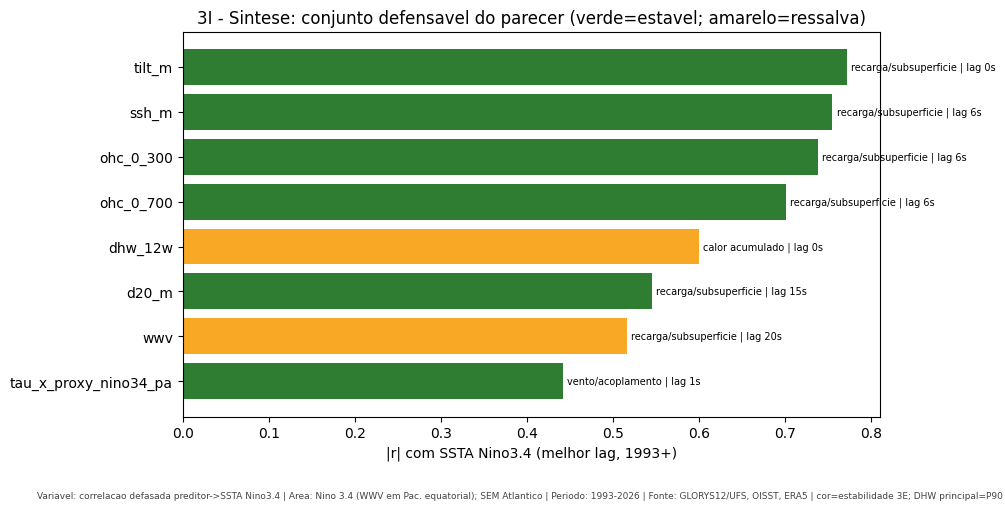

In [5]:
# figura-sintese: ranking com bloco e estabilidade
conc2=conc.sort_values('r',key=abs,ascending=False)
fig,ax=plt.subplots(figsize=(9,5))
cor=conc2['estavel_3E'].map({True:'#2e7d32',False:'#f9a825'})
ax.barh(conc2['variavel'],conc2['r'].abs(),color=cor)
for i,(_,r) in enumerate(conc2.iterrows()): ax.text(abs(r['r'])+.005,i,f"{r['bloco']} | lag {r['lag_semanas']}s",va='center',fontsize=7)
ax.invert_yaxis(); ax.set_xlabel('|r| com SSTA Nino3.4 (melhor lag, 1993+)')
ax.set_title('3I - Sintese: conjunto defensavel do parecer (verde=estavel; amarelo=ressalva)')
u.stamp_caption(fig,variavel='correlacao defasada preditor->SSTA Nino3.4',area='Nino 3.4 (WWV em Pac. equatorial); SEM Atlantico',periodo='1993-2026',fonte='GLORYS12/UFS, OISST, ERA5',extra='cor=estabilidade 3E; DHW principal=P90')
u.save_fig(fig,'phase3I_sintese_parecer.png'); plt.show()

**Veredito integrado (Pacifico).** O **bloco de recarga/subsuperficie domina** o Nino 3.4: tilt/SSH/OHC descrevem o estado acoplado de curto prazo (lag 0-6 sem), **D20 e o melhor precursor estavel de medio prazo (~15 sem)**, tau_x acopla no crescimento. **WWV** entra com ressalva (regime-dependente pos-2010). **DHW** e severidade/memoria curta, nao precursor longo. A classificacao executiva da Fase 3 agora tem apenas duas classes: `forte_p90` e `super_p95`; eventos abaixo de P90 sao descartados das analises por classe. **2026:** aquecimento em curso, junho parcial - nao fecha evento. A Fase 3 sustenta parecer fisico, nao skill preditivo (isso e a Fase 5).


In [6]:
# exporta texto integrado atualizado para o parecer
entra = ', '.join(conc.query("uso_parecer == 'entra'")['variavel'].tolist())
ressalva = ', '.join(conc.query("uso_parecer != 'entra'")['variavel'].tolist())
estado = est.iloc[0]
media_gt90 = media.query("grupo == 'eventos_gt_p90'").iloc[0]
texto = f"""# Interpretacao integrada da Fase 3

## Veredito executivo
A Fase 3 sustenta um diagnostico fisico auditavel do Nino 3.4 com OISST local, sem rotulo ENSO externo e sem ML. O bloco de recarga/subsuperficie domina a interpretacao: tilt/SSH/OHC descrevem o estado acoplado de curto prazo, D20 fornece antecedencia estavel de medio prazo e WWV aparece como relacao regime-dependente.

## DHW
O DHW principal da Fase 3 e `dhw_12w`: acumulo de C-week em 12 semanas acima do P90 diario local da SSTA OISST. `dhw_26w_p90` permanece como sensibilidade na escala do evento, pois sua janela aproxima o e-folding observado da SSTA (~27 semanas). Nenhuma das metricas deve ser usada como definicao de El Nino nem como precursor longo sem validacao preditiva.

## Relacoes que entram no parecer
Estaveis em 3D+3E: {entra}. Regime-dependentes/ressalva: {ressalva}. Relacoes instaveis entram como limitacao fisica, nao como descarte automatico.

## P90 e P95
`forte_p90` = evento com pico mensal >P90 e <P95. `super_p95` = evento com pico mensal >P95. Eventos abaixo ou iguais a P90 ficam registrados em tabela de descarte e nao entram nos compostos por classe.

## Media dos eventos >P90
O conjunto `eventos_gt_p90` tem {int(media_gt90['n_eventos'])} eventos, pico medio {media_gt90['pico_medio_c']} C, duracao media {media_gt90['duracao_media_meses']} meses e DHW maximo medio {media_gt90['dhw_maximo_medio_c_weeks']} C-weeks.

## Estado 2026
Ultimo dado diario OISST: {estado['ultimo_dia']}, SSTA diaria {estado['ssta_diaria_c']} C. Leitura: {estado['leitura']}.

## Proxima decisao
A Fase 3 pode alimentar um parecer fisico e preparar a Fase 5. Ela ainda nao prova skill preditivo. O proximo avanco deve testar se D20/OHC/SSH/tau_x/DHW superam climatologia e persistencia em walk-forward.
"""
out = u.STATS / 'phase3I_interpretacao_integrada.md'
out.write_text(texto, encoding='utf-8')
print(f"[texto] {out.relative_to(u.ROOT)}")


[texto] data\processed\parquet\statistics\phase3I_interpretacao_integrada.md
